# EDA — Fatores Urbanos (CompStat Rio)

Este notebook explora o dataset `fatores_urbanos.csv`, que registra **fatores urbanos**
(infraestrutura, conservação, iluminação, vegetação, ocupação irregular do espaço público
etc.) coletados em campo nas 8 Áreas de Força Municipal (FM) do Rio.

## Por que estes dados importam

Cada registro de fator urbano carrega **o órgão responsável** pela sua resolução
(COMLURB, SEOP, RioLuz, SMAS, SECONSERVA, CET-Rio, GM-Rio, SMTR). Isso transforma o
dataset numa **ponte direta entre os hot-spots de criminalidade e a ação operacional**:
sabemos não só *onde* o ambiente urbano está degradado, mas *quem na prefeitura tem a
caneta* para corrigir cada problema.

A análise abaixo busca responder:
- Quais tipos de fator urbano são mais comuns?
- Qual órgão municipal carrega a maior fila de demandas?
- Como esses fatores se distribuem entre bairros e áreas FM?
- Qual a "mix" de agências por área FM — quem precisa atuar onde?


## 1. Setup e carga

In [1]:
import os, sys, warnings
warnings.filterwarnings('ignore')
os.environ.setdefault('MPLCONFIGDIR', os.path.join(os.environ.get('TMPDIR', '/tmp'), 'matplotlib'))
os.makedirs(os.environ['MPLCONFIGDIR'], exist_ok=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from shapely.geometry import Point

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 160)

REPO = '/Users/alexandreguimaraes/Documents/Personal Projects/claude_impact/claude_impact_lab_compstat_rio'
CSV  = f'{REPO}/dados/fatores_urbanos.csv'
SHP  = f'{REPO}/sh_area_forca/areas_forca_municipal.shp'

df = pd.read_csv(CSV)
print('shape:', df.shape)
df.head(3)


shape: (2085, 31)
Out[1]: 
   id_resposta_ocorrencia            logradouro numero_porta referencia  coordenada_x  coordenada_y  observacao  endereco_informado valido  id_bairro  \
0                     732  Rua Coração de Maria          426        NaN    -22.891580    -43.274256         NaN               False    NaN         63   
1                     734  Rua Coração de Maria          406        NaN    -22.891878    -43.274529         NaN               False    NaN         63   
2                     705          Rua Cabrália           16        NaN    -22.858458    -43.374460  TRÊS PODAS               False    NaN         90   

       bairro_nome  id_tipo_pessoa  id_subarea              subarea_nome tipo_pessoa_descricao  id_ocupacao_pessoa ocupacao_pessoa_descricao  \
0            Meier             NaN        10.0  Estação Méier - Cachambi                   NaN                 NaN                       NaN   
1            Meier             NaN        10.0  Estação Méier - Cachambi

,id_resposta_ocorrencia,logradouro,numero_porta,referencia,coordenada_x,coordenada_y,observacao,endereco_informado,valido,id_bairro,bairro_nome,id_tipo_pessoa,id_subarea,subarea_nome,tipo_pessoa_descricao,id_ocupacao_pessoa,ocupacao_pessoa_descricao,id_tipo_frequencia,tipo_frequencia_descricao,ocupacao_drogas,ocupacao_drogas_descricao,id_item_praca,item_praca_descricao,id_tipo_ocorrencia,tipo_ocorrencia_descricao,tipo_ocorrencia_ativo,orgao_responsavel,ocorrencia_informacao,id_orgao_ocorrencia,ocorrencia_orgao_nome,codigo_ocorrencia_orgao
0,732,Rua Coração de Maria,426,NaN,-22.891580,-43.274256,NaN,False,NaN,63,Meier,NaN,10.0,Estação Méier - Cachambi,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,Vegetação obstruindo a visibilidade do passeio,True,COMLURB,O agente deve identificar se há presença de ve...,1,COMLURB,4351
1,734,Rua Coração de Maria,406,NaN,-22.891878,-43.274529,NaN,False,NaN,63,Meier,NaN,10.0,Estação Méier - Cachambi,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,Vegetação obstruindo a visibilidade do passeio,True,COMLURB,O agente deve identificar se há presença de ve...,1,COMLURB,4351
2,705,Rua Cabrália,16,NaN,-22.858458,-43.374460,TRÊS PODAS,False,NaN,90,Marechal Hermes,NaN,9.0,Estação Marechal Hermes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,Vegetação obstruindo a visibilidade do passeio,True,COMLURB,O agente deve identificar se há presença de ve...,1,COMLURB,4351


### Schema e missing

In [2]:
print('--- dtypes ---')
print(df.dtypes)
print()
print('--- missing (%) ---')
miss = (df.isna().mean() * 100).round(1).sort_values(ascending=False)
print(miss.to_string())


--- dtypes ---
id_resposta_ocorrencia         int64
logradouro                       str
numero_porta                     str
referencia                       str
coordenada_x                 float64
coordenada_y                 float64
observacao                       str
endereco_informado              bool
valido                        object
id_bairro                      int64
bairro_nome                      str
id_tipo_pessoa               float64
id_subarea                   float64
subarea_nome                     str
tipo_pessoa_descricao            str
id_ocupacao_pessoa           float64
ocupacao_pessoa_descricao        str
id_tipo_frequencia           float64
tipo_frequencia_descricao        str
ocupacao_drogas              float64
ocupacao_drogas_descricao        str
id_item_praca                float64
item_praca_descricao             str
id_tipo_ocorrencia             int64
tipo_ocorrencia_descricao        str
tipo_ocorrencia_ativo           bool
orgao_responsavel      

### Verificação do swap de coordenadas

**GOTCHA crítico:** as colunas `coordenada_x` e `coordenada_y` estão **trocadas**.
No Rio, latitude fica em torno de -22.x e longitude em torno de -43.x. Vamos confirmar
empiricamente e renomear para `lat` / `lon` antes de qualquer análise espacial.

In [3]:
print('coordenada_x.describe():')
print(df['coordenada_x'].describe())
print()
print('coordenada_y.describe():')
print(df['coordenada_y'].describe())
print()
print('Como coordenada_x ~ -22 (latitude do Rio) e coordenada_y ~ -43 (longitude do Rio),')
print('renomeamos: coordenada_x -> lat, coordenada_y -> lon')

df = df.rename(columns={'coordenada_x': 'lat', 'coordenada_y': 'lon'})
df[['lat', 'lon']].describe()


coordenada_x.describe():
count    2085.000000
mean      -22.928084
std         0.041772
min       -23.011439
25%       -22.965891
50%       -22.918880
75%       -22.894477
max       -22.821797
Name: coordenada_x, dtype: float64

coordenada_y.describe():
count    2085.000000
mean      -43.269982
std         0.111810
min       -43.684141
25%       -43.322822
50%       -43.220588
75%       -43.190337
max       -43.168814
Name: coordenada_y, dtype: float64

Como coordenada_x ~ -22 (latitude do Rio) e coordenada_y ~ -43 (longitude do Rio),
renomeamos: coordenada_x -> lat, coordenada_y -> lon
Out[3]: 
               lat          lon
count  2085.000000  2085.000000
mean    -22.928084   -43.269982
std       0.041772     0.111810
min     -23.011439   -43.684141
25%     -22.965891   -43.322822
50%     -22.918880   -43.220588
75%     -22.894477   -43.190337
max     -22.821797   -43.168814


,lat,lon
count,2085.000000,2085.000000
mean,-22.928084,-43.269982
std,0.041772,0.111810
min,-23.011439,-43.684141
25%,-22.965891,-43.322822
50%,-22.918880,-43.220588
75%,-22.894477,-43.190337
max,-22.821797,-43.168814


## 2. Distribuição por tipo de ocorrência

Quais tipos de fator urbano aparecem com mais frequência nos registros de campo?
Mostramos os 20 mais comuns.


Total de tipos distintos: 22
Top 6 concentram 1360 de 2085 registros (65.2%)


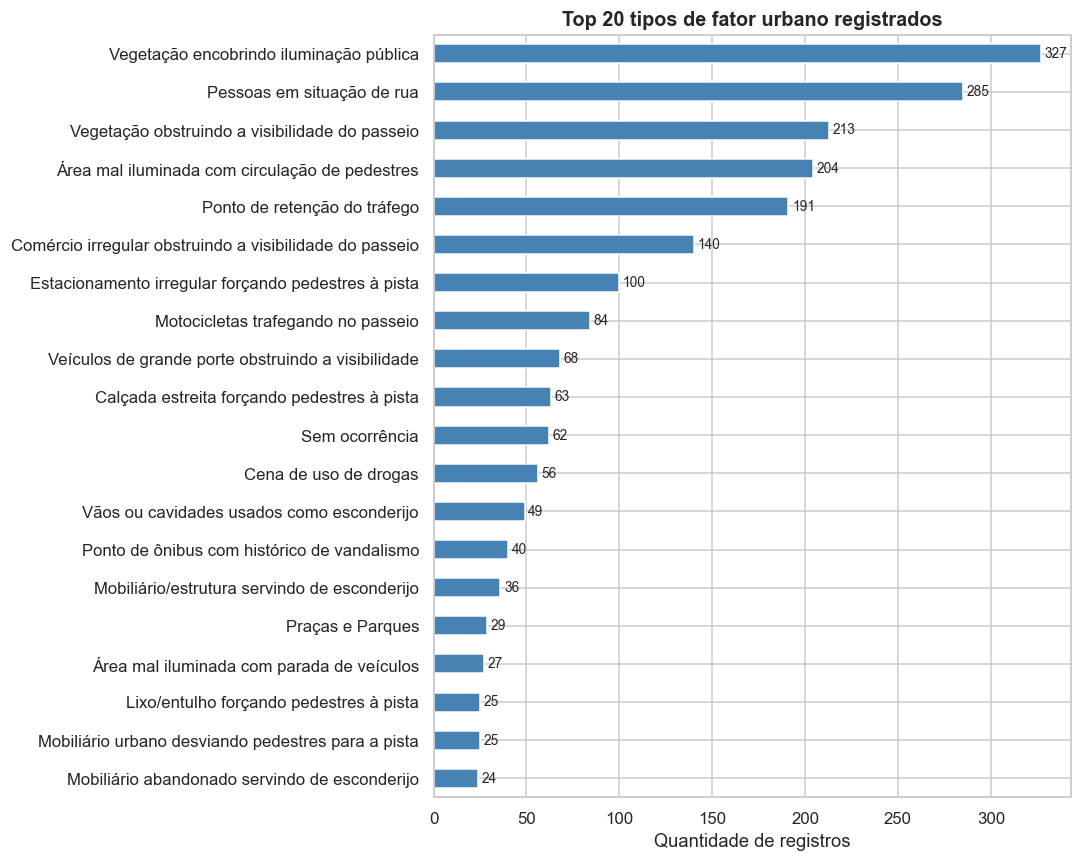

In [4]:
top_tipos = df['tipo_ocorrencia_descricao'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 8))
top_tipos.iloc[::-1].plot.barh(ax=ax, color='steelblue')
ax.set_title('Top 20 tipos de fator urbano registrados', fontsize=13, fontweight='bold')
ax.set_xlabel('Quantidade de registros')
ax.set_ylabel('')
for i, v in enumerate(top_tipos.iloc[::-1].values):
    ax.text(v + 2, i, str(v), va='center', fontsize=9)
plt.tight_layout()
plt.show()

print(f'\nTotal de tipos distintos: {df["tipo_ocorrencia_descricao"].nunique()}')
print(f'Top 6 concentram {top_tipos.head(6).sum()} de {len(df)} registros ({top_tipos.head(6).sum()/len(df)*100:.1f}%)')


## 3. Distribuição por órgão responsável

Cada fator urbano é encaminhado a um órgão municipal. A fila por órgão indica **carga
operacional** — quem tem mais trabalho pela frente para "limpar" o ambiente urbano nas
áreas FM.


Implicação operacional:
- COMLURB lidera com 583 demandas (28.0% do total)
  -> zeladoria/limpeza urbana é o principal gargalo do ambiente construído nas áreas FM
- Top 4 órgãos (['COMLURB', 'SMAS', 'SEOP', 'Rio Luz']) concentram 70.2% das demandas


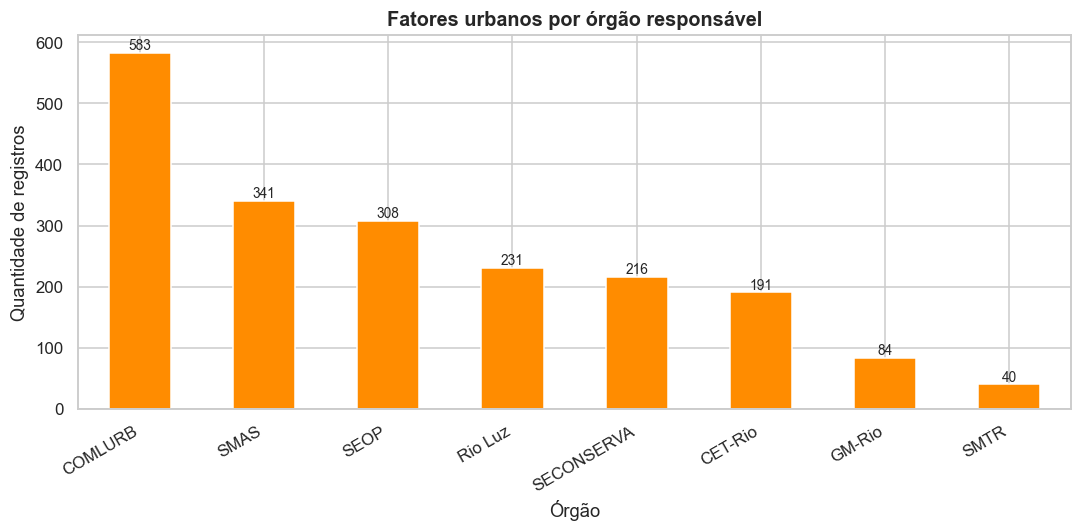

In [5]:
orgaos = df['orgao_responsavel'].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
orgaos.plot.bar(ax=ax, color='darkorange')
ax.set_title('Fatores urbanos por órgão responsável', fontsize=13, fontweight='bold')
ax.set_ylabel('Quantidade de registros')
ax.set_xlabel('Órgão')
plt.xticks(rotation=30, ha='right')
for i, v in enumerate(orgaos.values):
    ax.text(i, v + 5, str(v), ha='center', fontsize=9)
plt.tight_layout()
plt.show()

print('\nImplicação operacional:')
print(f'- COMLURB lidera com {orgaos.iloc[0]} demandas ({orgaos.iloc[0]/len(df)*100:.1f}% do total)')
print(f'  -> zeladoria/limpeza urbana é o principal gargalo do ambiente construído nas áreas FM')
print(f'- Top 4 órgãos ({orgaos.head(4).index.tolist()}) concentram {orgaos.head(4).sum()/len(df)*100:.1f}% das demandas')


## 4. Distribuição por bairro e por subárea (Área FM)

`subarea_nome` corresponde às 8 Áreas de Força Municipal (com alguns extras). `bairro_nome`
desce a granularidade.

Bairros distintos: 48
Subáreas distintas: 22


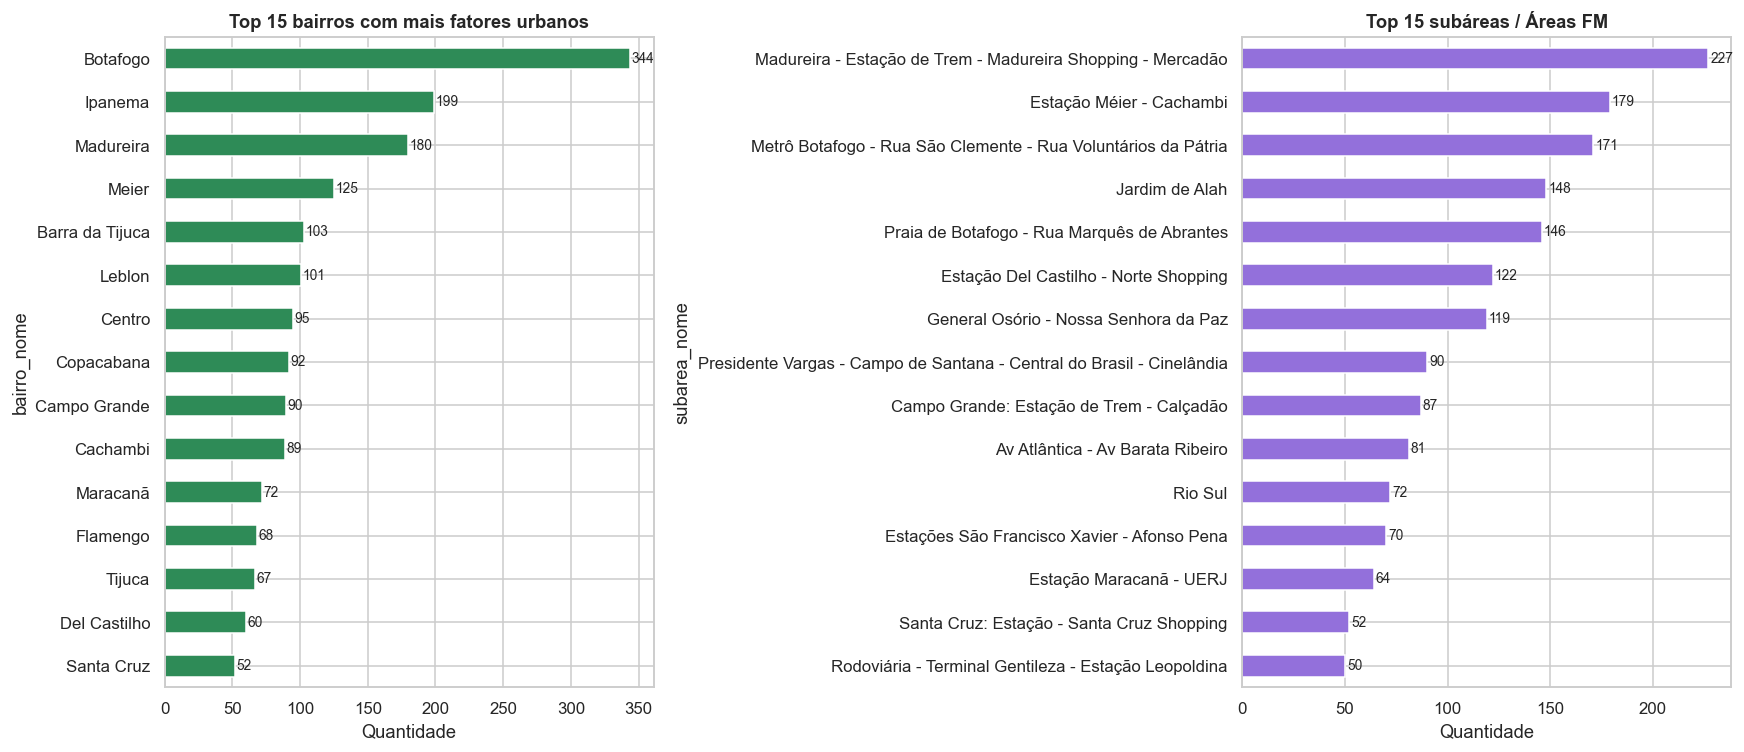

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

top_bairros = df['bairro_nome'].value_counts().head(15)
top_bairros.iloc[::-1].plot.barh(ax=axes[0], color='seagreen')
axes[0].set_title('Top 15 bairros com mais fatores urbanos', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Quantidade')
for i, v in enumerate(top_bairros.iloc[::-1].values):
    axes[0].text(v + 1, i, str(v), va='center', fontsize=9)

top_sub = df['subarea_nome'].value_counts().head(15)
top_sub.iloc[::-1].plot.barh(ax=axes[1], color='mediumpurple')
axes[1].set_title('Top 15 subáreas / Áreas FM', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Quantidade')
for i, v in enumerate(top_sub.iloc[::-1].values):
    axes[1].text(v + 1, i, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.show()

print(f'Bairros distintos: {df["bairro_nome"].nunique()}')
print(f'Subáreas distintas: {df["subarea_nome"].nunique()}')


## 5. Cruzamento órgão x subárea

Heatmap mostrando **qual órgão domina a fila em cada Área FM**. Isso responde
diretamente: *"se eu quero atuar na área X, com qual secretaria preciso falar primeiro?"*


Órgão dominante por subárea (top 5 subáreas):
  Madureira - Estação de Trem - Madureira Shopping - Mercadão: SEOP (68/225 = 30%)
  Estação Méier - Cachambi: COMLURB (107/175 = 61%)
  Metrô Botafogo - Rua São Clemente - Rua Voluntários da Pátria: COMLURB (73/167 = 44%)
  Jardim de Alah: SMAS (56/147 = 38%)
  Praia de Botafogo - Rua Marquês de Abrantes: Rio Luz (46/139 = 33%)


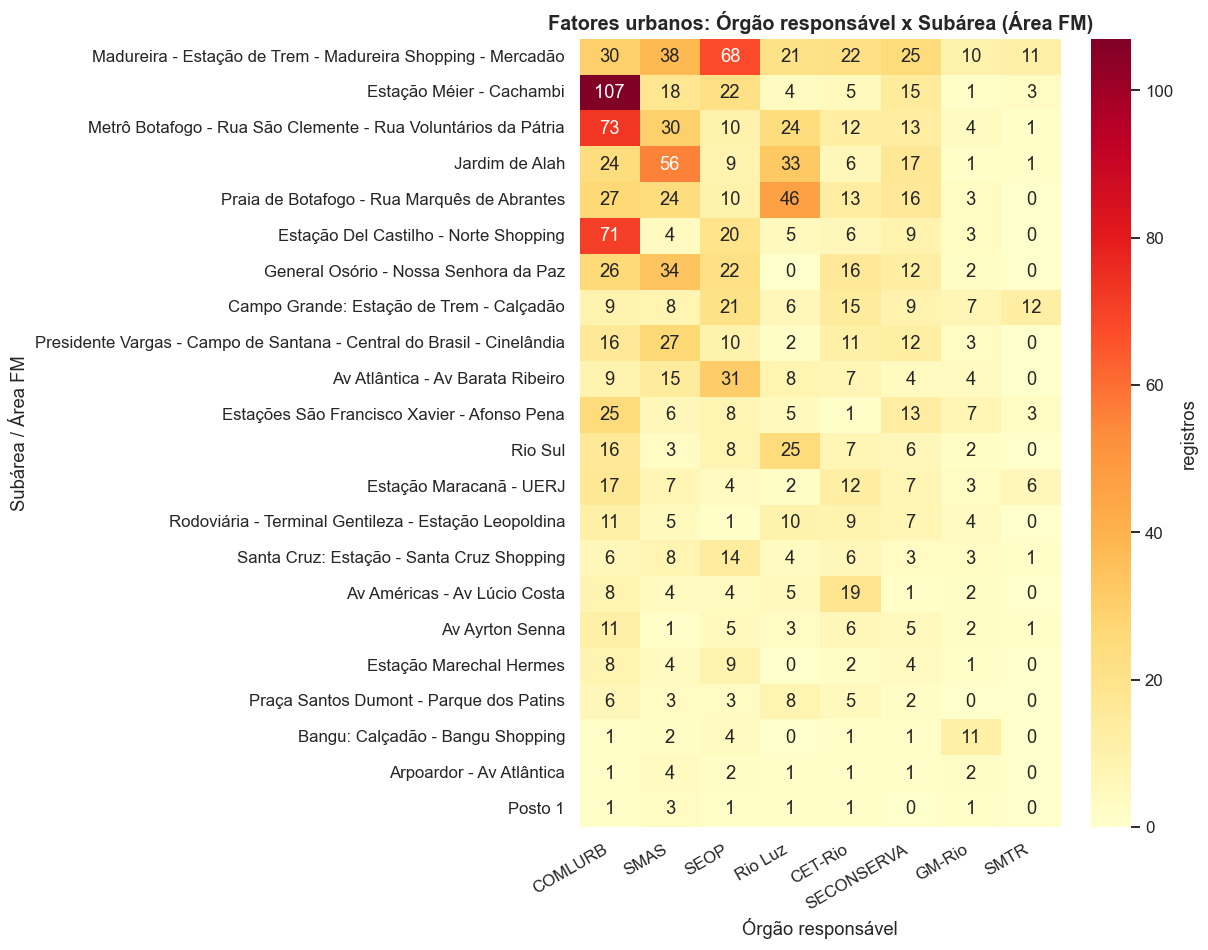

In [7]:
ct = pd.crosstab(df['subarea_nome'], df['orgao_responsavel'])
# ordena linhas pelo total decrescente
ct = ct.loc[ct.sum(axis=1).sort_values(ascending=False).index]
# ordena colunas por total
ct = ct[ct.sum(axis=0).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(11, max(5, 0.4 * len(ct))))
sns.heatmap(ct, annot=True, fmt='d', cmap='YlOrRd', cbar_kws={'label': 'registros'}, ax=ax)
ax.set_title('Fatores urbanos: Órgão responsável x Subárea (Área FM)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Órgão responsável')
ax.set_ylabel('Subárea / Área FM')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

print('\nÓrgão dominante por subárea (top 5 subáreas):')
for sub in ct.index[:5]:
    dom = ct.loc[sub].idxmax()
    val = ct.loc[sub].max()
    tot = ct.loc[sub].sum()
    print(f'  {sub}: {dom} ({val}/{tot} = {val/tot*100:.0f}%)')


## 6. Mapa geográfico — fatores coloridos por órgão

Com `lat`/`lon` corrigidos, plotamos cada fator urbano georreferenciado sobre os
polígonos das 8 Áreas FM (EPSG:4326).

In [8]:
# carrega shapefile das áreas FM
areas = gpd.read_file(SHP).to_crs(epsg=4326)
print('Áreas FM:', len(areas))
print('Colunas:', areas.columns.tolist())
areas.head()


Áreas FM: 8
Colunas: ['fid', 'nome_subar', 'geometry']
Out[8]: 
    fid                                         nome_subar                                           geometry
0   2.0  Rodoviária - Terminal Gentileza - Estação Leop...  POLYGON ((-43.21251 -22.89815, -43.21289 -22.8...
1   9.0  Metrô Botafogo - Rua São Clemente - Rua Volunt...  POLYGON ((-43.19636 -22.9525, -43.19578 -22.95...
2  10.0                                     Jardim de Alah  POLYGON ((-43.21838 -22.98006, -43.21846 -22.9...
3  11.0           Campo Grande: Estação de Trem - Calçadão  POLYGON ((-43.56256 -22.90247, -43.56289 -22.9...
4  12.0                                            Rio Sul  POLYGON ((-43.18037 -22.95593, -43.18092 -22.9...


,fid,nome_subar,geometry
0,2.0,Rodoviária - Terminal Gentileza - Estação Leop...,"POLYGON ((-43.21251 -22.89815, -43.21289 -22.8..."
1,9.0,Metrô Botafogo - Rua São Clemente - Rua Volunt...,"POLYGON ((-43.19636 -22.9525, -43.19578 -22.95..."
2,10.0,Jardim de Alah,"POLYGON ((-43.21838 -22.98006, -43.21846 -22.9..."
3,11.0,Campo Grande: Estação de Trem - Calçadão,"POLYGON ((-43.56256 -22.90247, -43.56289 -22.9..."
4,12.0,Rio Sul,"POLYGON ((-43.18037 -22.95593, -43.18092 -22.9..."


Pontos georreferenciados utilizáveis: 2085 de 2085


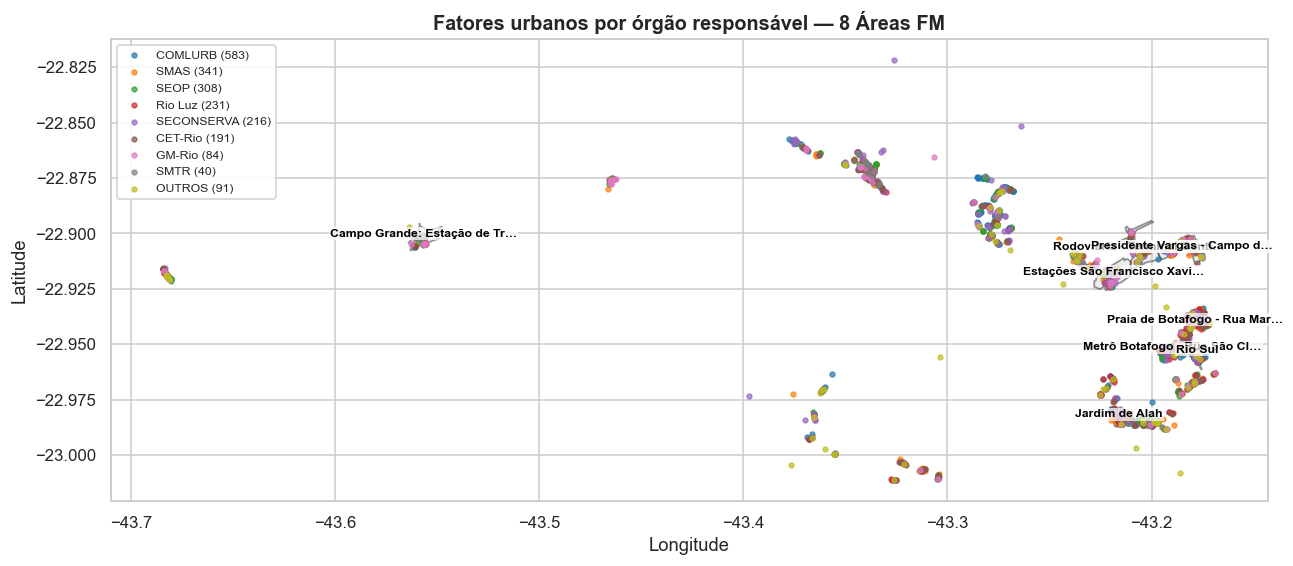

In [9]:
# filtra registros com coordenadas válidas e dentro de um bounding-box do Rio
m = df.dropna(subset=['lat', 'lon']).copy()
m = m[(m['lat'].between(-23.1, -22.7)) & (m['lon'].between(-43.8, -43.1))]
print(f'Pontos georreferenciados utilizáveis: {len(m)} de {len(df)}')

# top 8 órgãos para colorir; demais vão como 'outros'
top_org = df['orgao_responsavel'].value_counts().head(8).index.tolist()
m['orgao_plot'] = np.where(m['orgao_responsavel'].isin(top_org),
                           m['orgao_responsavel'], 'OUTROS')

fig, ax = plt.subplots(figsize=(12, 11))
areas.plot(ax=ax, facecolor='lightgrey', edgecolor='black', linewidth=1.2, alpha=0.4)

palette = sns.color_palette('tab10', n_colors=len(top_org) + 1)
for i, org in enumerate(top_org + ['OUTROS']):
    sub = m[m['orgao_plot'] == org]
    ax.scatter(sub['lon'], sub['lat'], s=10, alpha=0.7,
               color=palette[i], label=f'{org} ({len(sub)})')

# rotula áreas FM
name_col = None
for c in ['nome_subar', 'nome', 'Nome', 'NOME', 'area', 'AREA', 'nm_area']:
    if c in areas.columns:
        name_col = c
        break
def _short(name, n=28):
    s = str(name)
    return s if len(s) <= n else s[:n-1] + '…'

if name_col:
    for _, r in areas.iterrows():
        c = r.geometry.centroid
        ax.annotate(_short(r[name_col]), (c.x, c.y), fontsize=8,
                    ha='center', fontweight='bold', color='black',
                    bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

ax.set_title('Fatores urbanos por órgão responsável — 8 Áreas FM',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(loc='upper left', fontsize=8, framealpha=0.9)
plt.tight_layout()
plt.show()


## 7. Spatial join — fatores por Área FM

Atribuímos cada ponto à sua Área FM via spatial join e respondemos:
- Quantos fatores por área?
- Top 3 tipos por área?
- Mix de agências por área (stacked bar)?

In [10]:
gdf_pts = gpd.GeoDataFrame(
    m, geometry=gpd.points_from_xy(m['lon'], m['lat']), crs='EPSG:4326'
)
joined = gpd.sjoin(gdf_pts, areas, how='left', predicate='within')
print('Pontos atribuídos a uma área FM:', joined['index_right'].notna().sum(),
      'de', len(joined))

# escolhe coluna de nome da área
area_col = None
for c in ['nome_subar', 'nome', 'Nome', 'NOME', 'area', 'AREA', 'nm_area']:
    if c in joined.columns:
        area_col = c
        break
if area_col is None:
    area_col = 'index_right'
joined['area_fm'] = joined[area_col]
print('Coluna usada como nome da área:', area_col)
print('\nÁreas FM detectadas:')
print(joined['area_fm'].value_counts(dropna=False))


Pontos atribuídos a uma área FM: 834 de 2085
Coluna usada como nome da área: nome_subar

Áreas FM detectadas:
area_fm
NaN                                                                      1251
Metrô Botafogo - Rua São Clemente - Rua Voluntários da Pátria             171
Jardim de Alah                                                            148
Praia de Botafogo - Rua Marquês de Abrantes                               146
Presidente Vargas - Campo de Santana - Central do Brasil - Cinelândia      90
Campo Grande: Estação de Trem - Calçadão                                   87
Rio Sul                                                                    72
Estações São Francisco Xavier - Afonso Pena                                70
Rodoviária - Terminal Gentileza - Estação Leopoldina                       50
Name: count, dtype: int64


Nota: o spatial join atribui apenas pontos *dentro* dos 8 polígonos das Áreas FM.
Pontos em bairros vizinhos ficam de fora, por isso o total aqui é menor que 2085.


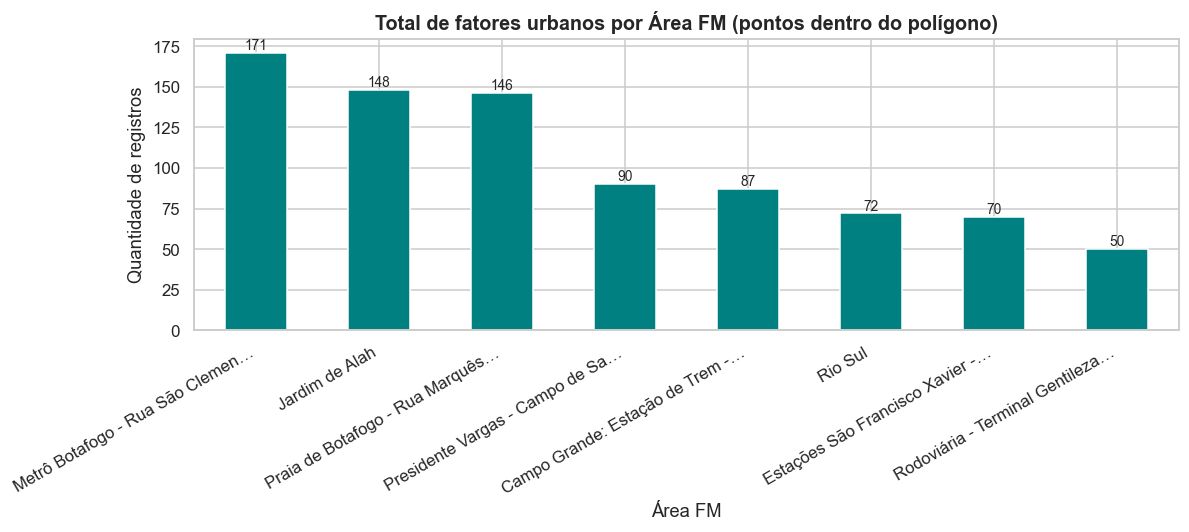

In [11]:
def _short(name, n=32):
    s = str(name)
    return s if len(s) <= n else s[:n-1] + '…'

# total de fatores por Área FM (mantém nomes completos no índice; encurta só na hora de plotar)
por_area = joined['area_fm'].value_counts().dropna()

fig, ax = plt.subplots(figsize=(11, 5))
por_area.rename(index=_short).plot.bar(ax=ax, color='teal')
ax.set_title('Total de fatores urbanos por Área FM (pontos dentro do polígono)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Quantidade de registros')
ax.set_xlabel('Área FM')
plt.xticks(rotation=30, ha='right')
for i, v in enumerate(por_area.values):
    ax.text(i, v + 2, str(int(v)), ha='center', fontsize=9)
plt.tight_layout()
plt.show()

print('Nota: o spatial join atribui apenas pontos *dentro* dos 8 polígonos das Áreas FM.')
print('Pontos em bairros vizinhos ficam de fora, por isso o total aqui é menor que 2085.')


In [12]:
# top 3 tipos por área
print('Top 3 tipos de fator urbano por Área FM:')
print('=' * 70)
for area in por_area.index:
    sub = joined[joined['area_fm'] == area]
    top3 = sub['tipo_ocorrencia_descricao'].value_counts().head(3)
    print(f'\n[{area}] — {len(sub)} registros')
    for tipo, n in top3.items():
        print(f'   {n:4d}  {tipo}')


Top 3 tipos de fator urbano por Área FM:

[Metrô Botafogo - Rua São Clemente - Rua Voluntários da Pátria] — 171 registros
     48  Vegetação encobrindo iluminação pública
     24  Pessoas em situação de rua
     21  Área mal iluminada com circulação de pedestres

[Jardim de Alah] — 148 registros
     53  Pessoas em situação de rua
     32  Área mal iluminada com circulação de pedestres
     18  Vegetação encobrindo iluminação pública

[Praia de Botafogo - Rua Marquês de Abrantes] — 146 registros
     37  Área mal iluminada com circulação de pedestres
     24  Pessoas em situação de rua
     21  Vegetação encobrindo iluminação pública

[Presidente Vargas - Campo de Santana - Central do Brasil - Cinelândia] — 90 registros
     22  Pessoas em situação de rua
     13  Vegetação encobrindo iluminação pública
     11  Ponto de retenção do tráfego

[Campo Grande: Estação de Trem - Calçadão] — 87 registros
     15  Ponto de retenção do tráfego
     12  Ponto de ônibus com histórico de vandalis

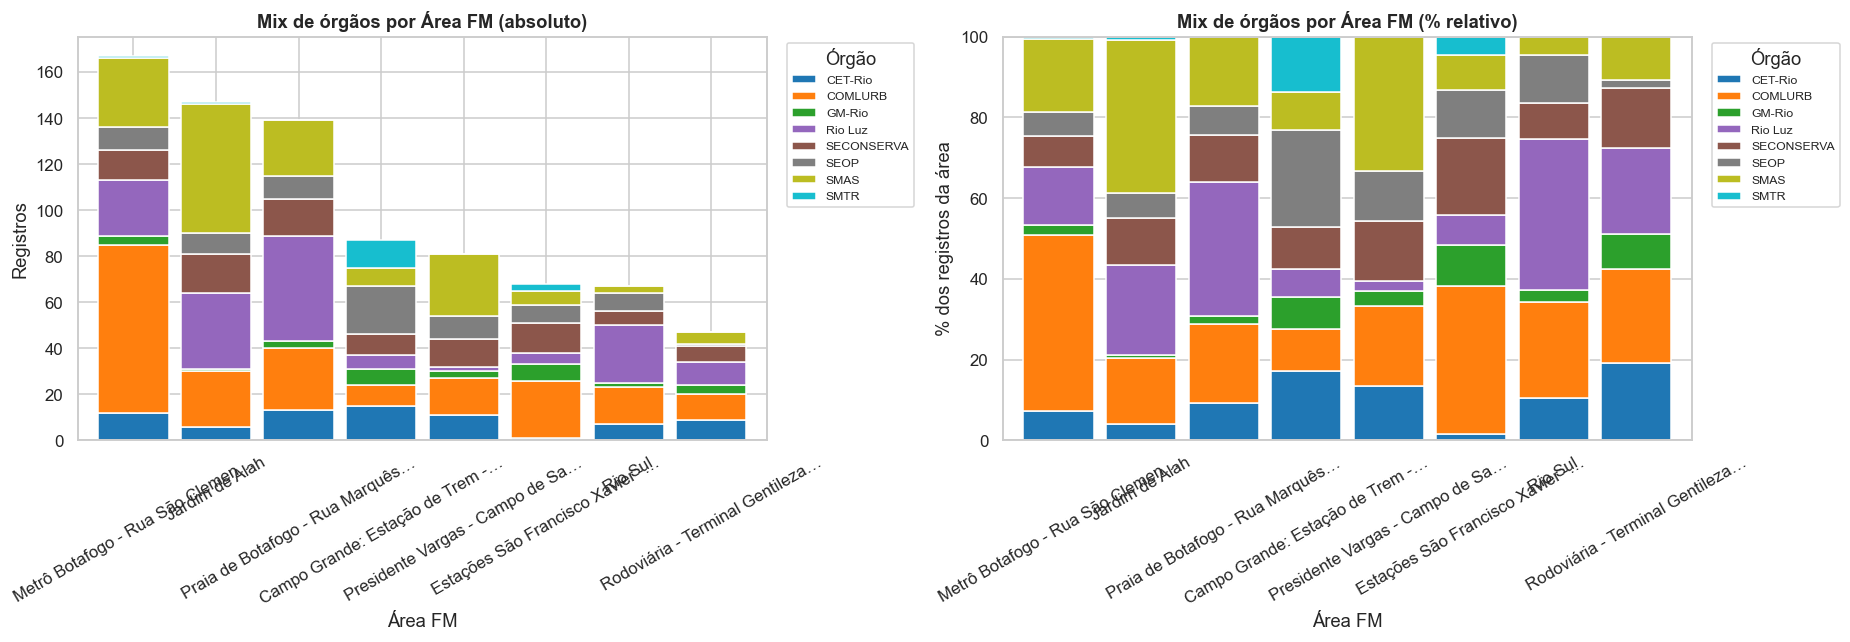

In [13]:
# mix de agências por área — stacked bar (proporção)
mix = pd.crosstab(joined['area_fm'], joined['orgao_responsavel'])
# ordena por volume
order = mix.sum(axis=1).sort_values(ascending=False).index
mix = mix.loc[order]
mix_pct = mix.div(mix.sum(axis=1), axis=0) * 100
# encurta apenas para o eixo
mix_plot = mix.copy(); mix_plot.index = [_short(x) for x in mix_plot.index]
mix_pct_plot = mix_pct.copy(); mix_pct_plot.index = [_short(x) for x in mix_pct_plot.index]

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

mix_plot.plot.bar(stacked=True, ax=axes[0], colormap='tab10', width=0.85)
axes[0].set_title('Mix de órgãos por Área FM (absoluto)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Registros')
axes[0].set_xlabel('Área FM')
axes[0].legend(title='Órgão', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
axes[0].tick_params(axis='x', rotation=30)

mix_pct_plot.plot.bar(stacked=True, ax=axes[1], colormap='tab10', width=0.85)
axes[1].set_title('Mix de órgãos por Área FM (% relativo)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('% dos registros da área')
axes[1].set_xlabel('Área FM')
axes[1].legend(title='Órgão', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
axes[1].tick_params(axis='x', rotation=30)
axes[1].set_ylim(0, 100)

plt.tight_layout()
plt.show()


## 8. Conclusões

**Takeaways operacionais para o CompStat Rio:**

1. **COMLURB é o gargalo dominante.** Concentra ~28% das demandas (583 registros),
   liderado por vegetação obstruindo iluminação/passeio. Qualquer plano de "limpar" o
   ambiente urbano das áreas FM passa por priorizar a fila da COMLURB.

2. **Top 4 órgãos respondem por ~70% das demandas.** COMLURB, SMAS, SEOP e RioLuz
   formam o núcleo da intervenção — uma força-tarefa entre esses quatro endereçaria a
   maioria dos fatores urbanos catalogados.

3. **Iluminação e vegetação são o eixo comum.** Os tipos mais frequentes (Vegetação
   encobrindo iluminação, Área mal iluminada, Vegetação obstruindo passeio) apontam
   para um mesmo vetor: visibilidade noturna degradada — o substrato físico clássico
   da percepção de insegurança.

4. **A "mix" de agências varia por Área FM.** Áreas com forte presença de comércio
   irregular (PSR, ambulantes) puxam SEOP/SMAS; áreas residenciais com vegetação
   intensa puxam COMLURB/RioLuz. O plano de ação deve ser **específico por área**, não
   genérico.

5. **As áreas mais carregadas (top do ranking) merecem intervenção piloto.** Concentrar
   um mutirão multi-agências nas 2-3 áreas FM com maior volume de fatores tende a
   produzir o maior retorno marginal sobre a percepção de ordem urbana.
